# Week 38 - Predict Phone Battery Life
### Simple Beginner Version - Every line explained

**What we are doing:**
We have a dataset of 1000 phones. Each phone has specs like battery size, screen size, RAM etc.
We want to build a model that can predict how long the battery will last (in hours).

**Dataset file:** phone_battery_dataset.csv

**How to use this notebook:**
- Run one cell at a time using Shift + Enter
- Read the comments (lines starting with #) before looking at the code
- Do not skip any cell - each one builds on the previous


---
## Step 1 - Import the tools we need
We need to import 3 things:
- **pandas** - to load and work with our data table
- **matplotlib** - to draw charts
- **scikit-learn** - for the machine learning models

In [2]:
# pandas helps us work with data tables (like Excel but in Python)
import pandas as pd
# matplotlib lets us draw charts and graphs
import matplotlib.pyplot as plt

import joblib
#import os
# These are the machine learning tools from scikit-learn
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score


print("All tools imported successfully!")


All tools imported successfully!


---
## Step 2 - Load the dataset

We load our CSV file into a variable called **df** (short for DataFrame).
A DataFrame is like a table - it has rows and columns.

Make sure **phone_battery_dataset.csv** is in the same folder as this notebook!


In [3]:
# pd.read_csv reads the CSV file and turns it into a table
df = pd.read_csv("phone_battery_dataset.csv")

# Print how many rows and columns we have
print("Number of rows (phones):", df.shape[0])
print("Number of columns:", df.shape[1])
print("")

# Print the column names so we know what data we have
print("Column names:")
print(df.columns.tolist())


Number of rows (phones): 1000
Number of columns: 12

Column names:
['Brand', 'OS', 'Screen_Size_in', 'RAM_GB', 'Battery_mAh', 'Processor_GHz', 'Num_Cores', 'Screen_Res', 'Has_5G', 'Weight_g', 'Price_USD', 'Battery_Life_hrs']


In [4]:
# Show the first 5 rows of the table
# This gives us a quick look at what the data looks like
df.head()


,Brand,OS,Screen_Size_in,RAM_GB,Battery_mAh,Processor_GHz,Num_Cores,Screen_Res,Has_5G,Weight_g,Price_USD,Battery_Life_hrs
0,Motorola,Android,5.2,2,4000,2.99,8,HD,1,223.4,458.54,7.5
1,Xiaomi,Android,6.5,2,5500,2.85,6,QHD,0,150.3,487.70,14.0
2,Nokia,Android,6.1,8,3500,3.27,8,QHD,0,144.7,611.31,5.9
3,Google,Android,4.8,8,3500,2.18,8,4K,1,215.6,670.78,5.8
4,Motorola,Android,7.0,12,2000,3.28,8,FHD,0,198.1,543.06,3.0


In [5]:
# Check if any values are missing (empty cells)
# If a column has missing values, we need to deal with them before training
print("Missing values in each column:")
print(df.isnull().sum())


Missing values in each column:
Brand               0
OS                  0
Screen_Size_in      0
RAM_GB              0
Battery_mAh         0
Processor_GHz       0
Num_Cores           0
Screen_Res          0
Has_5G              0
Weight_g            0
Price_USD           0
Battery_Life_hrs    0
dtype: int64


In [6]:
# Get basic statistics about the numbers in our dataset
# This shows min, max, average etc for each column
df.describe()


,Screen_Size_in,RAM_GB,Battery_mAh,Processor_GHz,Num_Cores,Has_5G,Weight_g,Price_USD,Battery_Life_hrs
count,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,5.85500,6.932000,4216.000000,2.619590,6.576000,0.658000,180.362500,610.767320,7.96150
std,0.76955,3.618352,922.602404,0.497172,1.553911,0.474617,29.310397,115.630147,2.95965
min,4.50000,2.000000,2000.000000,1.800000,4.000000,0.000000,130.100000,305.860000,3.00000
25%,5.20000,4.000000,3500.000000,2.190000,6.000000,0.000000,155.900000,530.315000,5.67500
50%,5.90000,6.000000,4000.000000,2.600000,6.000000,1.000000,179.450000,603.115000,8.10000
75%,6.50000,8.000000,5000.000000,3.060000,8.000000,1.000000,206.100000,681.785000,10.10000
max,7.20000,16.000000,6000.000000,3.500000,8.000000,1.000000,230.000000,1116.920000,16.20000


---
## Step 3 - Look at the data (EDA)

Before building any model, we always look at the data first.
We want to understand:
- What does the battery life (our target) look like?
- Are there obvious patterns?

**EDA stands for Exploratory Data Analysis** - it just means exploring your data with charts and numbers.


In [7]:
# Let us look at the column we want to predict: Battery_Life_hrs
print("Battery Life Statistics:")
print("Average:", round(df["Battery_Life_hrs"].mean(), 2), "hours")
print("Minimum:", df["Battery_Life_hrs"].min(), "hours")
print("Maximum:", df["Battery_Life_hrs"].max(), "hours")
print("Median:", df["Battery_Life_hrs"].median(), "hours")


Battery Life Statistics:
Average: 7.96 hours
Minimum: 3.0 hours
Maximum: 16.2 hours
Median: 8.1 hours


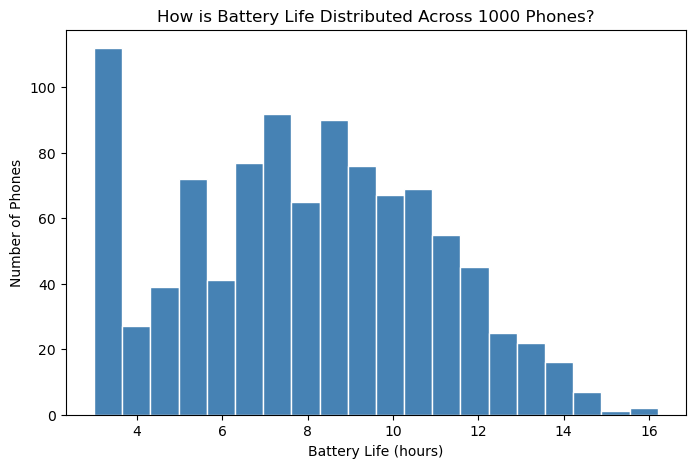

In [8]:
# Draw a histogram to see how battery life is distributed
# A histogram shows how many phones fall into each range

plt.figure(figsize=(8, 5))

# plt.hist draws the histogram
# bins=20 means divide the range into 20 groups
# color sets the bar colour
# edgecolor adds a white border around each bar
plt.hist(df["Battery_Life_hrs"], bins=20, color="steelblue", edgecolor="white")

# Add labels and a title so the chart makes sense
plt.xlabel("Battery Life (hours)")
plt.ylabel("Number of Phones")
plt.title("How is Battery Life Distributed Across 1000 Phones?")

plt.show()


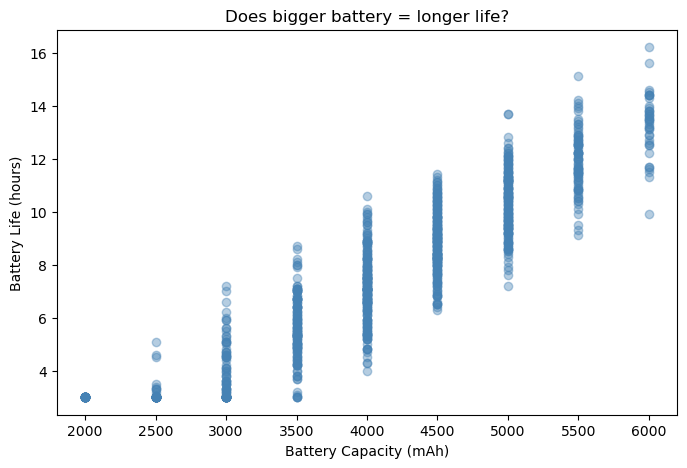

In [9]:
# Scatter plot: Battery capacity (mAh) vs Battery Life
# We expect: bigger battery = longer life
# If that is true, the dots should go from bottom-left to top-right

plt.figure(figsize=(8, 5))

# plt.scatter draws a scatter plot
# x = what goes on the horizontal axis
# y = what goes on the vertical axis
# alpha = transparency (0 = invisible, 1 = solid)
plt.scatter(df["Battery_mAh"], df["Battery_Life_hrs"], alpha=0.4, color="steelblue")

plt.xlabel("Battery Capacity (mAh)")
plt.ylabel("Battery Life (hours)")
plt.title("Does bigger battery = longer life?")

plt.show()
# If the dots go from bottom-left to top-right, there is a POSITIVE relationship


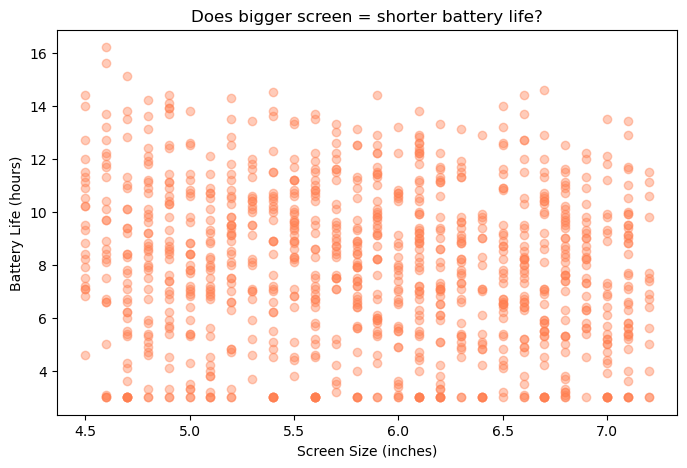

In [10]:
# Scatter plot: Screen Size vs Battery Life
# We expect: bigger screen = shorter battery life (screen uses more power)

plt.figure(figsize=(8, 5))

plt.scatter(df["Screen_Size_in"], df["Battery_Life_hrs"], alpha=0.4, color="coral")

plt.xlabel("Screen Size (inches)")
plt.ylabel("Battery Life (hours)")
plt.title("Does bigger screen = shorter battery life?")

plt.show()
# If dots go from top-left to bottom-right, there is a NEGATIVE relationship


iOS average battery life:     8.83 hours
Android average battery life: 7.85 hours


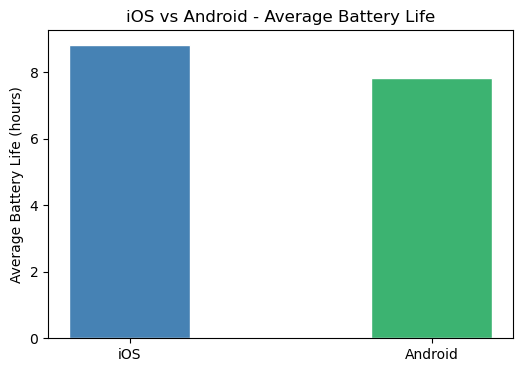

In [11]:
# Compare battery life for iOS vs Android
# We separate the data into two groups and compare

ios_battery = df[df["OS"] == "iOS"]["Battery_Life_hrs"]
android_battery = df[df["OS"] == "Android"]["Battery_Life_hrs"]

print("iOS average battery life:    ", round(ios_battery.mean(), 2), "hours")
print("Android average battery life:", round(android_battery.mean(), 2), "hours")

# Draw a bar chart to compare
plt.figure(figsize=(6, 4))

# We manually give the heights of the bars
heights = [ios_battery.mean(), android_battery.mean()]
labels = ["iOS", "Android"]

plt.bar(labels, heights, color=["steelblue", "mediumseagreen"], edgecolor="white", width=0.4)

plt.ylabel("Average Battery Life (hours)")
plt.title("iOS vs Android - Average Battery Life")

plt.show()


In [12]:
# Check how much each column is correlated with Battery_Life_hrs
# Correlation tells us: if this feature increases, does battery life increase or decrease?
# Values close to 1 or -1 mean strong relationship
# Values close to 0 mean weak/no relationship

# We only pick the numeric columns for this
numeric_columns = ["Screen_Size_in", "RAM_GB", "Battery_mAh",
                   "Processor_GHz", "Num_Cores", "Has_5G",
                   "Weight_g", "Price_USD", "Battery_Life_hrs"]

# Calculate correlations
correlations = df[numeric_columns].corr()

# Show only the correlations WITH Battery_Life_hrs
battery_corr = correlations["Battery_Life_hrs"].drop("Battery_Life_hrs")
battery_corr_sorted = battery_corr.sort_values()

print("Correlation of each feature with Battery Life:")
print("(Positive = increases battery, Negative = decreases battery)")
print("")
print(battery_corr_sorted.round(3))


Correlation of each feature with Battery Life:
(Positive = increases battery, Negative = decreases battery)

RAM_GB           -0.206
Screen_Size_in   -0.131
Has_5G           -0.108
Processor_GHz    -0.048
Weight_g          0.004
Num_Cores         0.031
Price_USD         0.089
Battery_mAh       0.914
Name: Battery_Life_hrs, dtype: float64


---
## Step 4 - Prepare the data for the model

Machine learning models only understand **numbers**.
Our dataset has text columns like "iOS", "Android", "HD", "FHD".
We need to convert these text values into numbers.

This is called **encoding**.


In [13]:
# Step 4a: Convert the OS column (iOS / Android) into numbers
# We will create a new column called OS_number
# Android = 0
# iOS = 1

# Create an empty list to store the numbers
os_numbers = []

# Go through every row in the OS column
for os_value in df["OS"]:
    if os_value == "iOS":
        os_numbers.append(1)   # iOS becomes 1
    else:
        os_numbers.append(0)   # Android becomes 0

# Add this new list as a column in our table
df["OS_number"] = os_numbers

print("First 10 values in OS column:")
print(df[["OS", "OS_number"]].head(10).to_string())


First 10 values in OS column:
        OS  OS_number
0  Android          0
1  Android          0
2  Android          0
3  Android          0
4  Android          0
5  Android          0
6  Android          0
7  Android          0
8  Android          0
9  Android          0


In [14]:
# Step 4b: Convert Screen Resolution (HD / FHD / QHD / 4K) into numbers
# We cannot use 0,1,2,3 because that would imply a fake ranking
# Instead we create 3 separate yes/no columns (called one-hot encoding)

# Create empty lists for each resolution type
is_fhd = []
is_hd = []
is_qhd = []
# Note: if all three are 0, the phone has 4K - we do not need a 4th column

for res in df["Screen_Res"]:
    if res == "FHD":
        is_fhd.append(1)
        is_hd.append(0)
        is_qhd.append(0)
    elif res == "HD":
        is_fhd.append(0)
        is_hd.append(1)
        is_qhd.append(0)
    elif res == "QHD":
        is_fhd.append(0)
        is_hd.append(0)
        is_qhd.append(1)
    else:
        # Must be 4K - all three are 0
        is_fhd.append(0)
        is_hd.append(0)
        is_qhd.append(0)

df["Res_FHD"] = is_fhd
df["Res_HD"] = is_hd
df["Res_QHD"] = is_qhd

print("Screen resolution columns created!")
print(df[["Screen_Res", "Res_FHD", "Res_HD", "Res_QHD"]].head(10).to_string())


Screen resolution columns created!
  Screen_Res  Res_FHD  Res_HD  Res_QHD
0         HD        0       1        0
1        QHD        0       0        1
2        QHD        0       0        1
3         4K        0       0        0
4        FHD        1       0        0
5         HD        0       1        0
6        QHD        0       0        1
7        FHD        1       0        0
8        FHD        1       0        0
9        QHD        0       0        1


In [16]:
# Step 4c: Now pick the columns we will use to train the model
# These are our FEATURES (inputs)
# We drop the original text columns since we already encoded them

feature_columns = [
    "Screen_Size_in",
    "RAM_GB",
    "Battery_mAh",
    "Processor_GHz",
    "Num_Cores",
    "Has_5G",
    "Weight_g",
    "Price_USD",
    "OS_number",
    "Res_FHD",
    "Res_HD",
    "Res_QHD"
]

# X = the features (inputs to our model)
X = df[feature_columns]
X

# y = the target (what we want to predict)
y = df["Battery_Life_hrs"]

print("X shape (features):", X.shape)
print("y shape (target):", y.shape)
print("")
print("Features we will use:")
for col in feature_columns:
    print(" -", col)
X


X shape (features): (1000, 12)
y shape (target): (1000,)

Features we will use:
 - Screen_Size_in
 - RAM_GB
 - Battery_mAh
 - Processor_GHz
 - Num_Cores
 - Has_5G
 - Weight_g
 - Price_USD
 - OS_number
 - Res_FHD
 - Res_HD
 - Res_QHD


,Screen_Size_in,RAM_GB,Battery_mAh,Processor_GHz,Num_Cores,Has_5G,Weight_g,Price_USD,OS_number,Res_FHD,Res_HD,Res_QHD
0,5.2,2,4000,2.99,8,1,223.4,458.54,0,0,1,0
1,6.5,2,5500,2.85,6,0,150.3,487.70,0,0,0,1
2,6.1,8,3500,3.27,8,0,144.7,611.31,0,0,0,1
3,4.8,8,3500,2.18,8,1,215.6,670.78,0,0,0,0
4,7.0,12,2000,3.28,8,0,198.1,543.06,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
995,5.7,6,3000,3.05,8,1,141.4,543.86,0,1,0,0
996,6.9,6,4500,2.71,4,1,164.2,644.34,0,1,0,0
997,4.8,16,3500,3.23,6,0,226.5,665.46,0,1,0,0
998,7.2,6,5500,2.38,8,1,180.9,646.97,0,1,0,0


---
## Step 5 - Split data into Training and Test sets

We cannot train and test on the same data.

**Why?** Imagine you give a student the exam questions AND answers to study.
They score 100% but they just memorised - they did not actually learn.

Same problem with ML models. If we test on data the model already saw,
the score will be fake (too high).

**Solution:** Keep 20% of data hidden. Train on 80%. Test on the hidden 20%.


In [49]:
# train_test_split automatically splits our data
# test_size=0.2 means 20% goes to the test set
# random_state=42 means the split will be the same every time we run this

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training set size:", X_train.shape[0], "phones")
print("Test set size:    ", X_test.shape[0], "phones")
print("")
print("The model will LEARN from the training set")
print("The model will be TESTED on the test set (it never saw these phones)")


Training set size: 800 phones
Test set size:     200 phones

The model will LEARN from the training set
The model will be TESTED on the test set (it never saw these phones)


---
## Step 6 - Train Model 1: Linear Regression

Linear Regression is the simplest model.

It tries to find a formula like this:
```
Battery Life = (weight1 x Battery_mAh) + (weight2 x Screen_Size) + ... + a_number
```

The model learns the best weights during training.

**Think of it as:** drawing the best straight line through your scatter plot.


In [50]:
# Create the Linear Regression model
model1 = LinearRegression()

# Train it on the training data
# .fit() is where the actual learning happens
# The model looks at 800 phones and their battery lives and finds the best weights
model1.fit(X_train, y_train)

print("Model 1 (Linear Regression) trained successfully!")


Model 1 (Linear Regression) trained successfully!


In [51]:
# Now use the trained model to predict battery life for the test phones
# These are the 200 phones the model has never seen before

predictions_model1 = model1.predict(X_test)

print("Predictions made for", len(predictions_model1), "phones")
print("")
print("First 10 predictions vs actual values:")
print("")

for i in range(10):
    predicted = round(predictions_model1[i], 1)
    actual = round(y_test.values[i], 1)
    difference = round(abs(predicted - actual), 1)
    print("Phone", i+1, "| Predicted:", predicted, "h | Actual:", actual, "h | Off by:", difference, "h")


Predictions made for 200 phones

First 10 predictions vs actual values:

Phone 1 | Predicted: 10.0 h | Actual: 10.9 h | Off by: 0.9 h
Phone 2 | Predicted: 3.5 h | Actual: 3.6 h | Off by: 0.1 h
Phone 3 | Predicted: 5.4 h | Actual: 5.8 h | Off by: 0.4 h
Phone 4 | Predicted: 4.4 h | Actual: 4.7 h | Off by: 0.3 h
Phone 5 | Predicted: 12.4 h | Actual: 12.0 h | Off by: 0.4 h
Phone 6 | Predicted: 4.9 h | Actual: 5.1 h | Off by: 0.2 h
Phone 7 | Predicted: 1.5 h | Actual: 3.0 h | Off by: 1.5 h
Phone 8 | Predicted: 8.3 h | Actual: 8.6 h | Off by: 0.3 h
Phone 9 | Predicted: 8.2 h | Actual: 7.1 h | Off by: 1.1 h
Phone 10 | Predicted: 9.4 h | Actual: 10.9 h | Off by: 1.5 h


In [52]:
# Evaluate how good Model 1 is

# MAE = Mean Absolute Error
# This is the average amount we are wrong by
# If MAE = 1.5, we are off by 1.5 hours on average
mae1 = mean_absolute_error(y_test, predictions_model1)

# R2 = R-squared score
# This tells us what percentage of the data variation our model explains
# 1.0 = perfect model   0.0 = useless model
r2_1 = r2_score(y_test, predictions_model1)

print("=== Model 1: Linear Regression Results ===")
print("")
print("MAE  =", round(mae1, 3), "hours")
print("  (on average our prediction is off by", round(mae1, 2), "hours)")
print("")
print("R2   =", round(r2_1, 4))
print("  (our model explains", round(r2_1 * 100, 1), "% of the variation in battery life)")


=== Model 1: Linear Regression Results ===

MAE  = 0.7 hours
  (on average our prediction is off by 0.7 hours)

R2   = 0.9116
  (our model explains 91.2 % of the variation in battery life)


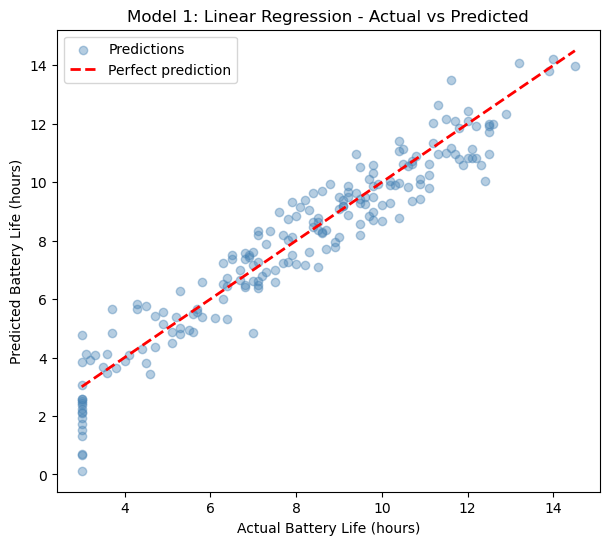

Dots close to the red line = good predictions
Dots far from the red line = bad predictions


In [53]:
# Scatter plot: Actual vs Predicted for Model 1
# If the model was perfect, every dot would sit on the diagonal line

plt.figure(figsize=(7, 6))

# Draw the dots
plt.scatter(y_test, predictions_model1, alpha=0.4, color="steelblue", label="Predictions")

# Draw the perfect prediction line (diagonal)
min_val = y_test.min()
max_val = y_test.max()
plt.plot([min_val, max_val], [min_val, max_val],
         color="red", linestyle="--", linewidth=2, label="Perfect prediction")

plt.xlabel("Actual Battery Life (hours)")
plt.ylabel("Predicted Battery Life (hours)")
plt.title("Model 1: Linear Regression - Actual vs Predicted")
plt.legend()

plt.show()

print("Dots close to the red line = good predictions")
print("Dots far from the red line = bad predictions")


---
## Step 7 - Train Model 2: Gradient Boosting

Gradient Boosting is more powerful than Linear Regression.

Instead of one formula, it builds **many small decision trees**.
Each tree fixes the mistakes of the previous one.

**Simple example:**
- Tree 1 predicts: 8.0 hours  (actual is 10.0 hours, off by 2.0)
- Tree 2 looks at that 2.0 error and says: add 1.5 more hours
- Tree 3 looks at the remaining 0.5 error and says: add 0.4 more hours
- ...and so on for 200 trees

Final answer = sum of all corrections

This is why it handles complex patterns much better than Linear Regression.


In [54]:
# Create the Gradient Boosting model with settings
# n_estimators = how many trees to build
# max_depth = how many questions each tree can ask
# learning_rate = how big each correction step is (smaller = more careful)
# random_state = makes results the same every time we run

model2 = GradientBoostingRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.08,
    random_state=42
)

# Train the model
model2.fit(X_train, y_train)

print("Model 2 (Gradient Boosting) trained successfully!")
print("It just built 200 decision trees!")


Model 2 (Gradient Boosting) trained successfully!
It just built 200 decision trees!


In [55]:
# Predict battery life for the test phones

predictions_model2 = model2.predict(X_test)

print("Predictions made for", len(predictions_model2), "phones")
print("")
print("First 10 predictions vs actual values:")
print("")

for i in range(10):
    predicted = round(predictions_model2[i], 1)
    actual = round(y_test.values[i], 1)
    difference = round(abs(predicted - actual), 1)
    print("Phone", i+1, "| Predicted:", predicted, "h | Actual:", actual, "h | Off by:", difference, "h")


Predictions made for 200 phones

First 10 predictions vs actual values:

Phone 1 | Predicted: 10.0 h | Actual: 10.9 h | Off by: 0.9 h
Phone 2 | Predicted: 3.9 h | Actual: 3.6 h | Off by: 0.3 h
Phone 3 | Predicted: 4.7 h | Actual: 5.8 h | Off by: 1.1 h
Phone 4 | Predicted: 3.9 h | Actual: 4.7 h | Off by: 0.8 h
Phone 5 | Predicted: 13.5 h | Actual: 12.0 h | Off by: 1.5 h
Phone 6 | Predicted: 3.9 h | Actual: 5.1 h | Off by: 1.2 h
Phone 7 | Predicted: 3.4 h | Actual: 3.0 h | Off by: 0.4 h
Phone 8 | Predicted: 8.5 h | Actual: 8.6 h | Off by: 0.1 h
Phone 9 | Predicted: 8.0 h | Actual: 7.1 h | Off by: 0.9 h
Phone 10 | Predicted: 9.1 h | Actual: 10.9 h | Off by: 1.8 h


In [56]:
# Evaluate Model 2

mae2 = mean_absolute_error(y_test, predictions_model2)
r2_2 = r2_score(y_test, predictions_model2)

print("=== Model 2: Gradient Boosting Results ===")
print("")
print("MAE  =", round(mae2, 3), "hours")
print("  (on average our prediction is off by", round(mae2, 2), "hours)")
print("")
print("R2   =", round(r2_2, 4))
print("  (our model explains", round(r2_2 * 100, 1), "% of the variation in battery life)")


=== Model 2: Gradient Boosting Results ===

MAE  = 0.75 hours
  (on average our prediction is off by 0.75 hours)

R2   = 0.8997
  (our model explains 90.0 % of the variation in battery life)


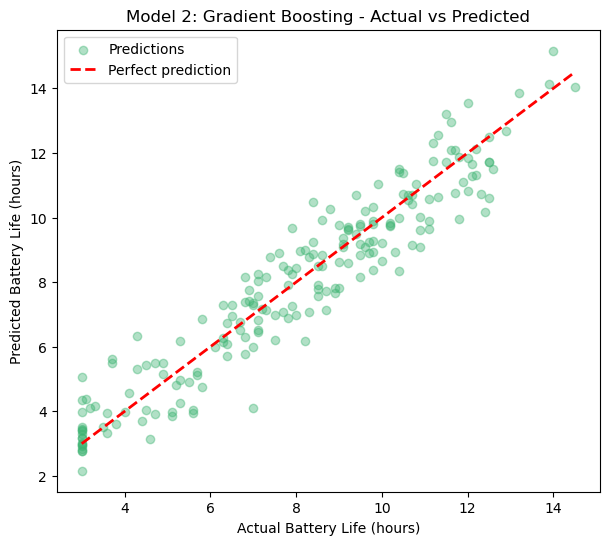

In [57]:
# Scatter plot: Actual vs Predicted for Model 2

plt.figure(figsize=(7, 6))

plt.scatter(y_test, predictions_model2, alpha=0.4, color="mediumseagreen", label="Predictions")

min_val = y_test.min()
max_val = y_test.max()
plt.plot([min_val, max_val], [min_val, max_val],
         color="red", linestyle="--", linewidth=2, label="Perfect prediction")

plt.xlabel("Actual Battery Life (hours)")
plt.ylabel("Predicted Battery Life (hours)")
plt.title("Model 2: Gradient Boosting - Actual vs Predicted")
plt.legend()

plt.show()


---
## Step 8 - Compare both models

Now we put both models side by side to see which one performed better.

**What we want:**
- Lower MAE = better (smaller average error)
- Higher R2 = better (explains more of the data)


In [58]:
# Print a comparison table

print("=" * 45)
print("       MODEL COMPARISON")
print("=" * 45)
print("")
print("Metric          Model 1 (LR)    Model 2 (GB)")
print("-" * 45)
print("MAE (hours)     ", round(mae1, 3), "          ", round(mae2, 3))
print("R2 score        ", round(r2_1, 4), "          ", round(r2_2, 4))
print("R2 (%)          ", round(r2_1 * 100, 1), "%           ", round(r2_2 * 100, 1), "%")
print("")

if r2_2 > r2_1:
    improvement = round((r2_2 - r2_1) * 100, 1)
    print("Winner: Model 2 (Gradient Boosting)")
    print("It improved R2 by", improvement, "percentage points over Linear Regression")
else:
    print("Winner: Model 1 (Linear Regression)")


       MODEL COMPARISON

Metric          Model 1 (LR)    Model 2 (GB)
---------------------------------------------
MAE (hours)      0.7            0.75
R2 score         0.9116            0.8997
R2 (%)           91.2 %            90.0 %

Winner: Model 1 (Linear Regression)


In [59]:
# Bar chart comparing the two models

models = ["Linear Regression", "Gradient Boosting"]
mae_values = [mae1, mae2]
r2_values = [r2_1, r2_2]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left chart: MAE comparison (lower is better)
axes[0].bar(models, mae_values, color=["steelblue", "mediumseagreen"], edgecolor="white", width=0.4)
axes[0].set_ylabel("MAE (hours)")
axes[0].set_title("MAE Comparison
(lower is better)")

# Add the value on top of each bar
for i, val in enumerate(mae_values):
    axes[0].text(i, val + 0.02, str(round(val, 3)), ha="center", fontweight="bold")

# Right chart: R2 comparison (higher is better)
axes[1].bar(models, r2_values, color=["steelblue", "mediumseagreen"], edgecolor="white", width=0.4)
axes[1].set_ylabel("R2 Score")
axes[1].set_title("R2 Score Comparison
(higher is better)")
axes[1].set_ylim(0, 1.1)

# Add the value on top of each bar
for i, val in enumerate(r2_values):
    axes[1].text(i, val + 0.02, str(round(val, 4)), ha="center", fontweight="bold")

plt.tight_layout()
plt.show()


SyntaxError: unterminated string literal (detected at line 12) (3053268179.py, line 12)

---
## Step 9 - Which features matter most?

Gradient Boosting tells us which features it used the most when making predictions.
This is called **Feature Importance**.

A feature with high importance had a big impact on the predictions.
A feature with low importance barely changed anything.


In [60]:
# Get the importance score for each feature
# feature_importances_ is a list of numbers between 0 and 1
# They all add up to 1.0 (100%)

importance_scores = model2.feature_importances_

# Pair each feature name with its score
feature_importance_pairs = []
for i in range(len(feature_columns)):
    feature_importance_pairs.append((feature_columns[i], importance_scores[i]))

# Sort by importance score from highest to lowest
feature_importance_pairs.sort(key=lambda x: x[1], reverse=True)

print("Feature Importance (most important first):")
print("")
print("Feature                  Score    Visual")
print("-" * 55)

for name, score in feature_importance_pairs:
    # Create a simple bar using the * character
    bar = "*" * int(score * 50)
    print(f"{name:25s}  {score:.4f}   {bar}")


Feature Importance (most important first):

Feature                  Score    Visual
-------------------------------------------------------
Battery_mAh                0.8644   *******************************************
Screen_Size_in             0.0318   *
RAM_GB                     0.0278   *
Price_USD                  0.0204   *
Processor_GHz              0.0150   
Has_5G                     0.0128   
Weight_g                   0.0113   
OS_number                  0.0112   
Num_Cores                  0.0028   
Res_QHD                    0.0011   
Res_HD                     0.0009   
Res_FHD                    0.0004   


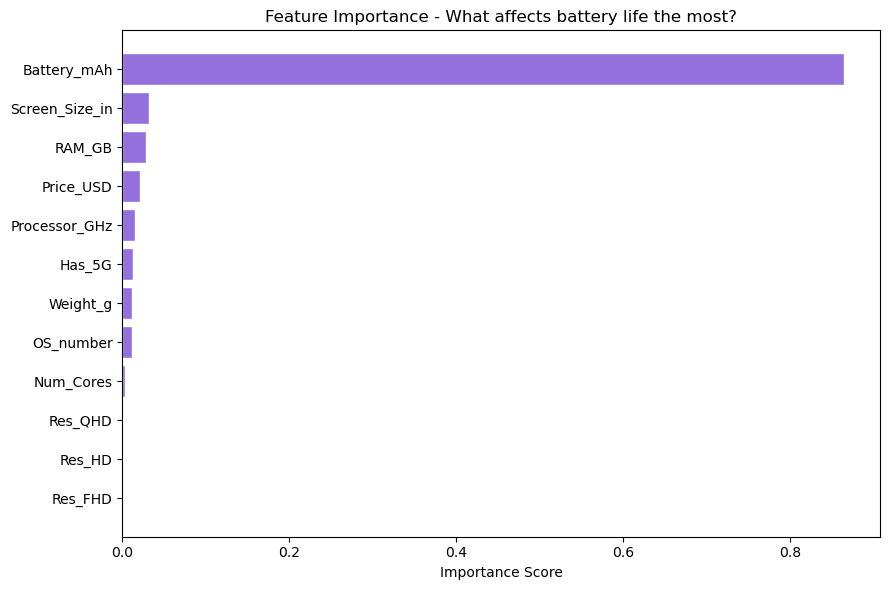

The features at the TOP of the chart had the biggest impact on predictions.


In [61]:
# Draw a horizontal bar chart of feature importance

names = [pair[0] for pair in feature_importance_pairs]
scores = [pair[1] for pair in feature_importance_pairs]

plt.figure(figsize=(9, 6))

# Reverse the order so the most important is at the top
plt.barh(names[::-1], scores[::-1], color="mediumpurple", edgecolor="white")

plt.xlabel("Importance Score")
plt.title("Feature Importance - What affects battery life the most?")

plt.tight_layout()
plt.show()

print("The features at the TOP of the chart had the biggest impact on predictions.")


---
## Step 10 - Predict battery life for your own phone!

Now the fun part. You can describe any phone you want and the model will predict how long its battery will last.

Just change the numbers in the cell below.


In [62]:
# Describe your phone here
# Change these numbers to match any phone you want to test

screen_size  = 6.1     # screen size in inches (between 4.5 and 7.2)
ram          = 8       # RAM in GB (choose from: 2, 3, 4, 6, 8, 12, 16)
battery_mah  = 4500    # battery capacity in mAh (between 2000 and 6000)
processor    = 2.8     # processor speed in GHz (between 1.8 and 3.5)
cores        = 8       # number of cores (choose from: 4, 6, 8)
has_5g       = 1       # does it have 5G? (1 = yes, 0 = no)
weight       = 175     # weight in grams (between 130 and 230)
price        = 799     # price in USD
os           = 1       # operating system (1 = iOS, 0 = Android)

# Screen resolution - only set ONE of these to 1, the rest to 0
# If you want 4K, set all three to 0
res_fhd = 1            # 1 if FHD screen
res_hd  = 0            # 1 if HD screen
res_qhd = 0            # 1 if QHD screen

print("Phone you described:")
print("  Screen size :", screen_size, "inches")
print("  RAM         :", ram, "GB")
print("  Battery     :", battery_mah, "mAh")
print("  Processor   :", processor, "GHz with", cores, "cores")
print("  5G          :", "Yes" if has_5g == 1 else "No")
print("  OS          :", "iOS" if os == 1 else "Android")
print("  Price       : $" + str(price))


Phone you described:
  Screen size : 6.1 inches
  RAM         : 8 GB
  Battery     : 4500 mAh
  Processor   : 2.8 GHz with 8 cores
  5G          : Yes
  OS          : iOS
  Price       : $799


In [63]:
# Put all the values into a list in the same order as our training features
my_phone = [[
    screen_size,
    ram,
    battery_mah,
    processor,
    cores,
    has_5g,
    weight,
    price,
    os,
    res_fhd,
    res_hd,
    res_qhd
]]

# Use Model 2 (Gradient Boosting) to make the prediction
predicted_hours = model2.predict(my_phone)[0]

print("=" * 40)
print("PREDICTION RESULT")
print("=" * 40)
print("")
print("Predicted battery life:", round(predicted_hours, 1), "hours")
print("")

# Give it a rating
if predicted_hours >= 12:
    print("Rating: EXCELLENT battery life!")
elif predicted_hours >= 8:
    print("Rating: GOOD battery life")
elif predicted_hours >= 5:
    print("Rating: AVERAGE battery life")
else:
    print("Rating: POOR battery life")

print("")
print("Try changing Battery_mAh to 6000 and run again to see how much it helps!")


PREDICTION RESULT

Predicted battery life: 10.1 hours

Rating: GOOD battery life

Try changing Battery_mAh to 6000 and run again to see how much it helps!


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(


In [68]:
joblib.dump(model1, 'model1.joblib')
#joblib.dump(scaler,'scaler.joblib')

['model1.joblib']

---
## Step 11 - Summary of what you learned

Congratulations! You just built a full machine learning project from scratch.


In [65]:
print("=" * 55)
print("   WEEK 38 SUMMARY")
print("=" * 55)
print("")
print("WHAT WE DID:")
print("  1. Loaded 1000 phones from a CSV file")
print("  2. Explored the data with charts and statistics")
print("  3. Converted text columns to numbers (encoding)")
print("  4. Split data into training (800) and test (200) sets")
print("  5. Trained Linear Regression - simple baseline model")
print("  6. Trained Gradient Boosting - powerful tree model")
print("  7. Compared both models using MAE and R2")
print("  8. Found which features matter most")
print("  9. Made a prediction for a custom phone")
print("")
print("FINAL SCORES:")
print("  Linear Regression  - MAE:", round(mae1, 2), "h  | R2:", round(r2_1, 3))
print("  Gradient Boosting  - MAE:", round(mae2, 2), "h  | R2:", round(r2_2, 3))
print("")
print("KEY THINGS TO REMEMBER:")
print("  - MAE = how many hours off on average (lower is better)")
print("  - R2  = how much of the pattern the model understood (higher is better)")
print("  - Always split data into train and test before building any model")
print("  - Text columns must be converted to numbers before training")
print("  - Gradient Boosting is almost always better than Linear Regression")
print("")
print("NEXT STEPS TO TRY:")
print("  - Change n_estimators to 50 and see if the score drops")
print("  - Change test_size to 0.3 (30% test) and see what changes")
print("  - Try predicting with different phone specs in Step 10")


   WEEK 38 SUMMARY

WHAT WE DID:
  1. Loaded 1000 phones from a CSV file
  2. Explored the data with charts and statistics
  3. Converted text columns to numbers (encoding)
  4. Split data into training (800) and test (200) sets
  5. Trained Linear Regression - simple baseline model
  6. Trained Gradient Boosting - powerful tree model
  7. Compared both models using MAE and R2
  8. Found which features matter most
  9. Made a prediction for a custom phone

FINAL SCORES:
  Linear Regression  - MAE: 0.7 h  | R2: 0.912
  Gradient Boosting  - MAE: 0.75 h  | R2: 0.9

KEY THINGS TO REMEMBER:
  - MAE = how many hours off on average (lower is better)
  - R2  = how much of the pattern the model understood (higher is better)
  - Always split data into train and test before building any model
  - Text columns must be converted to numbers before training
  - Gradient Boosting is almost always better than Linear Regression

NEXT STEPS TO TRY:
  - Change n_estimators to 50 and see if the score drops